In [51]:
print('test')

test


## 1. Import Library 및 데이터 원본 폴더 설정

In [52]:
# 라이브러리 가져오기
import numpy as np
import pandas as pd
import plotly
import plotly.io as pio
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## 2. 데이터 가져오기 및 테이블 결합


In [53]:
# 데이터 가져오기
# read_csv: CSV(Comma-Separated Values) 파일을 읽어 DataFrame으로 변환하는 함수
df_orders = pd.read_csv("data\olist_orders_dataset.csv")
df_order_items = pd.read_csv("data\olist_order_items_dataset.csv")
df_payments = pd.read_csv("data\olist_order_payments_dataset.csv")
df_products = pd.read_csv("data\olist_products_dataset.csv")
df_translate = pd.read_csv("data\product_category_name_translation.csv")
df_geo = pd.read_csv("data\olist_geolocation_dataset.csv")
df_customers = pd.read_csv("data\olist_customers_dataset.csv")
df_sellers = pd.read_csv("data\olist_sellers_dataset.csv")
df_reviews = pd.read_csv("data\olist_order_reviews_dataset.csv")

# 테이블 결합
# merge(df1, df2, how='inner', on='key'): 두 개의 DataFrame을 특정 키를 기준으로 결합하는 함수
df = pd.merge(df_orders, df_order_items[['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']], on='order_id')
df = pd.merge(df, df_products[['product_id', 'product_category_name']], on='product_id')
df = pd.merge(df, df_translate[['product_category_name', 'product_category_name_english']], on='product_category_name')
df = pd.merge(df, df_customers[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city','customer_state']], on='customer_id')
df = pd.merge(df, df_sellers[['seller_id', 'seller_zip_code_prefix', 'seller_city','seller_state']], on='seller_id')

rv = df_reviews.groupby('order_id')['review_score'].mean().reset_index()
df = pd.merge(df, rv, on='order_id', how='left')
# 테이블 조회
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,utilidades_domesticas,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumaria,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,automotivo,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842,belo horizonte,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,papelaria,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752,mogi das cruzes,SP,5.0


## 3. 리뷰 및 배송 지연 분석 

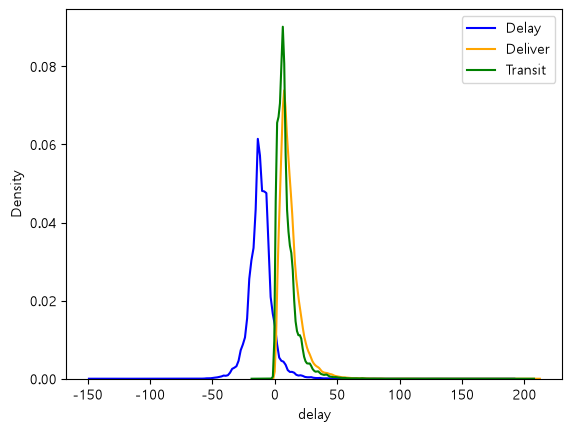

-11.342257290589558
12.46888652148644
9.19008763646063
2.844530997876643


In [54]:
# to_datetime으로 변환
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
# order_delivered_customer_date: 고객에게 실제 배송된 일자
# order_estimated_delivery_date: 구매 시점에 고객에게 안내된 예상 배송일


# order_approved_at: 결제 승인
# 60(1분=60초) * 60(1시간=60분) * 24(1일=24시간) (1일 = 86,400초)
df['delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds() / (3600 * 24)
df['deliver'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (3600 * 24)
df['transit'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / (3600 * 24)
df['preprocessing'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / (3600 * 24)
#가격변수
df['value'] =  df['price']+df['freight_value']
 
# 라인차트 생성
sns.kdeplot(df['delay'], label='Delay', color='blue')
sns.kdeplot(df['deliver'], label='Deliver', color='orange')
sns.kdeplot(df['transit'], label='Transit', color='green')
plt.legend()
plt.show()

# 평균값 표시
print(df['delay'].mean())
print(df['deliver'].mean())
print(df['transit'].mean())
print(df['preprocessing'].mean())

# 실제 상품이 deliver가 된 평균일자는 12일이고, 예상보다 지연된 평균일자는 -11일이다.
# 예상 배송일자보다 빠르게 배송되고 있지만, 실제 배송일은 12일로 비교적 배송일이 느리다.
# carrier로부터 고객에게 배송되는 transit은 평균 9일이며 deliver에서 transit을 뺀 판매자의 준비시간은 평균 3일 정도로 transit이 가장 큰 비중을 차지한다. 따라서, 배송지연을 줄이기 위해서는 transit을 줄이는 것이 가장 효과적이다.


In [55]:
# 데이터 필터링 
# 기간 설정 및 배달완료건만 

df = df[df['order_status']=='delivered']
df = df[(df['order_purchase_timestamp']>='2017-01-01') &
        (df['order_purchase_timestamp']<='2018-06-30 23:59:59')]
df = df[(df['transit']>=0) & (df['preprocessing']>=0)]          # 데이터 역전 제거
df = df.dropna(subset=['transit','preprocessing','deliver'])
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,price,freight_value,customer_zip_code_prefix,seller_zip_code_prefix,review_score,delay,deliver,transit,preprocessing,value
count,93437,93437,93437,93437,93437,93437.000000,93437.000000,93437.000000,93437.000000,93437.000000,92700.000000,93437.000000,93437.000000,93437.000000,93437.000000,93437.000000
mean,2017-12-03 10:25:30.753352,2017-12-03 20:22:03.873604,2017-12-06 18:34:41.746974,2017-12-16 12:47:22.331870,2017-12-28 01:28:21.231846,1.201537,119.997177,19.722638,35451.044843,24411.361591,4.058545,-11.528459,13.098514,9.758803,2.925438,139.719815
min,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1.000000,0.850000,0.000000,1004.000000,1001.000000,1.000000,-146.016123,0.533414,0.000000,0.000174,6.080000
25%,2017-08-25 13:38:17,2017-08-25 21:05:19,2017-08-29 13:47:21,2017-09-05 21:24:41,2017-09-19 00:00:00,1.000000,39.900000,13.080000,11680.000000,6429.000000,4.000000,-16.506539,7.077870,4.337940,0.944537,55.220000
50%,2017-12-18 18:19:07,2017-12-19 09:51:41,2017-12-21 16:46:54,2018-01-05 19:23:16,2018-01-16 00:00:00,1.000000,74.900000,16.150000,24936.000000,13800.000000,5.000000,-12.220891,10.924676,7.307153,1.928843,91.910000
75%,2018-03-25 15:56:25,2018-03-25 22:28:02,2018-03-28 04:03:54,2018-04-10 15:28:56,2018-04-17 00:00:00,1.000000,134.490000,20.880000,59213.000000,27277.000000,5.000000,-7.179155,16.276273,12.788218,3.730498,157.350000
max,2018-06-30 23:59:49,2018-07-05 16:24:37,2018-08-07 09:34:00,2018-10-17 13:22:46,2018-09-03 00:00:00,21.000000,6735.000000,409.680000,99980.000000,99730.000000,5.000000,188.975081,209.628611,205.190972,107.053218,6929.310000
std,NaN,NaN,NaN,NaN,NaN,0.722187,180.324427,15.132484,29862.580514,27556.627640,1.359038,10.283813,9.747575,8.969494,3.452207,187.038219


### 데이터프레임 구분
-  df: 거리·셀러위치·허브 분석
-  df_order: 배송시간·만족(order_id에따른 review부여로 중복되는 order_id제외)

In [56]:
# ① 배송 구간 분해 — transit이 몸통인지 확인 (Tableau의 83% 재현)
print(df[['deliver','preprocessing','transit']].describe())
df.groupby('review_score')[['deliver','preprocessing','transit']].mean()

            deliver  preprocessing       transit
count  93437.000000   93437.000000  93437.000000
mean      13.098514       2.925438      9.758803
std        9.747575       3.452207      8.969494
min        0.533414       0.000174      0.000000
25%        7.077870       0.944537      4.337940
50%       10.924676       1.928843      7.307153
75%       16.276273       3.730498     12.788218
max      209.628611     107.053218    205.190972


,deliver,preprocessing,transit
review_score,,,
1.000000,20.620945,4.163893,15.992528
1.500000,14.874045,2.021568,12.679850
2.000000,16.537110,3.561283,12.541757
2.500000,16.432744,4.699788,11.341066
3.000000,14.641508,3.257394,10.941623
3.333333,22.033148,0.549236,20.959861
3.500000,12.802536,3.786663,8.629737
4.000000,12.757800,2.898006,9.444733
4.333333,3.765359,1.692697,1.068623


In [57]:
# 주문별 대표 카테고리 + 주문 총액
rep = (df.groupby(['order_id','product_category_name_english'])
         .agg(n=('order_item_id','count'), v=('value','sum')).reset_index()
         .sort_values(['order_id','n','v'], ascending=[True,False,False])
         .drop_duplicates('order_id')[['order_id','product_category_name_english']]
         .rename(columns={'product_category_name_english':'main_category'}))
order_val = df.groupby('order_id')['value'].sum().rename('order_value').reset_index()

df_order = (df.drop_duplicates('order_id')
              .merge(rep, on='order_id', how='left')
              .merge(order_val, on='order_id', how='left'))
display(df_order)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_city,seller_state,review_score,delay,deliver,transit,preprocessing,value,main_category,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,4.0,-7.107488,8.436574,6.062650,2.366493,38.71,housewares,38.71
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,belo horizonte,MG,5.0,-12.980069,13.208750,9.450498,3.745833,72.20,pet_shop,72.20
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,mogi das cruzes,SP,5.0,-9.238171,2.873877,1.937824,0.893113,28.62,stationery,28.62
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1,060cb19345d90064d1015407193c233d,...,guarulhos,SP,4.0,-5.543113,16.542245,14.833229,1.699896,175.26,auto,175.26
4,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1,4520766ec412348b8d4caa5e8a18c464,...,atibaia,SP,5.0,-11.461215,9.989826,4.116725,5.864988,75.16,auto,75.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81691,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1,ac35486adb7b02598c182c2ff2e05254,...,braganca paulista,SP,5.0,-10.369433,8.218009,7.159699,1.058310,85.08,health_beauty,85.08
81692,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,tupa,SP,4.0,-1.265324,22.193727,20.760579,1.425058,195.00,baby,195.00
81693,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,sao paulo,SP,5.0,-5.524803,24.859421,23.605451,1.241782,271.01,home_appliances_2,271.01
81694,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,ilicinea,MG,2.0,-20.018819,17.086424,13.331840,3.749097,220.58,computers_accessories,441.16


deliver_bin
~10日       4.386208
11~20日     4.223636
21~30日     3.694110
31~40日     2.488493
41~50日     1.812874
51~100日    1.746881
Name: review_score, dtype: float64


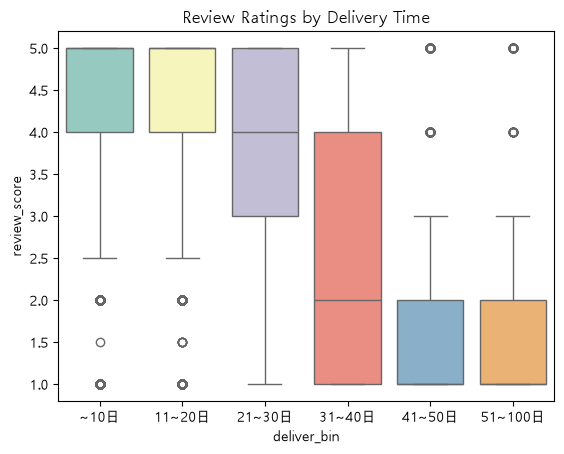

In [58]:
import seaborn as sns, matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 한글/한자 폰트
plt.rcParams['axes.unicode_minus'] = False 

# A-1. 배송 시간대별 평균 리뷰
df_order['deliver_bin'] = pd.cut(df_order['deliver'], [0,10,20,30
                                                    ,40, 50, 100],
                                 labels=['~10日','11~20日','21~30日','31~40日','41~50日','51~100日'])
print(df_order.groupby('deliver_bin')['review_score'].mean())

# A-2. 박스플롯
sns.boxplot(x='deliver_bin', y='review_score', data=df_order, palette='Set3')
plt.title('Review Ratings by Delivery Time'); plt.show()

지연 주문 비중: 8.3%
is_late
0    4.283103
1    2.448615
Name: review_score, dtype: float64


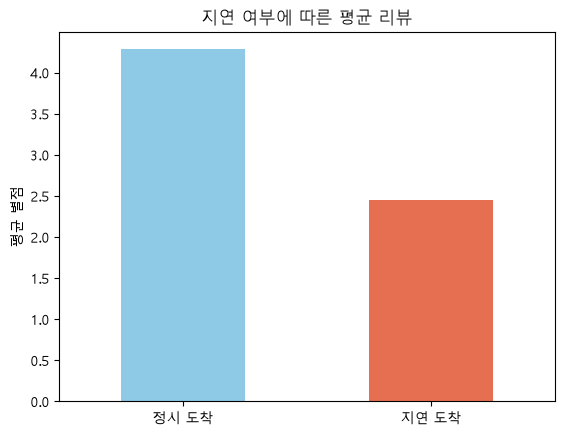

In [59]:
# B-1. 지연 주문 비중
df_order['is_late'] = (df_order['delay'] > 0).astype(int)
print(f"지연 주문 비중: {df_order['is_late'].mean()*100:.1f}%")   # 약 7.9%

# B-2. 지연 vs 정시 평균 리뷰
print(df_order.groupby('is_late')['review_score'].mean())

# B-3. 막대그래프
g = df_order.groupby('is_late')['review_score'].mean()
g.index = ['정시 도착','지연 도착']
g.plot(kind='bar', color=['#8ecae6','#e76f51'], rot=0)
plt.title('지연 여부에 따른 평균 리뷰'); plt.ylabel('평균 별점'); plt.show()

=> 30일 이상 걸린 주문을 대상으로 지역별 배송 지연을 분석해보자.


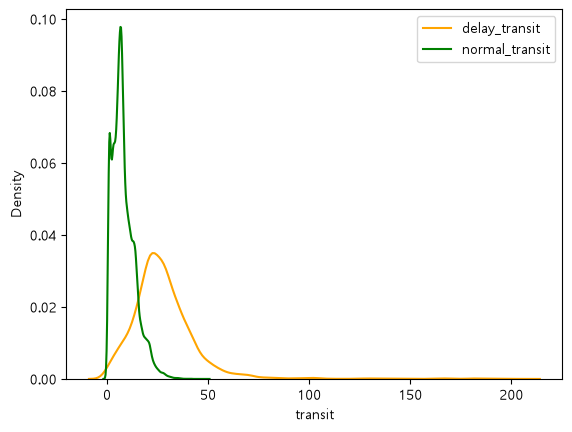

In [60]:
df_order.groupby('is_late')['deliver'].mean()
# 라인차트 생성
df_delay = df_order[df_order['is_late']==1]
df_normal = df_order[df_order['is_late']==0]



sns.kdeplot(df_delay['transit'], label='delay_transit', color='orange')
sns.kdeplot(df_normal['transit'], label='normal_transit', color='green')
plt.legend()
plt.show()

## 4. 지역별 배송 지연 분석

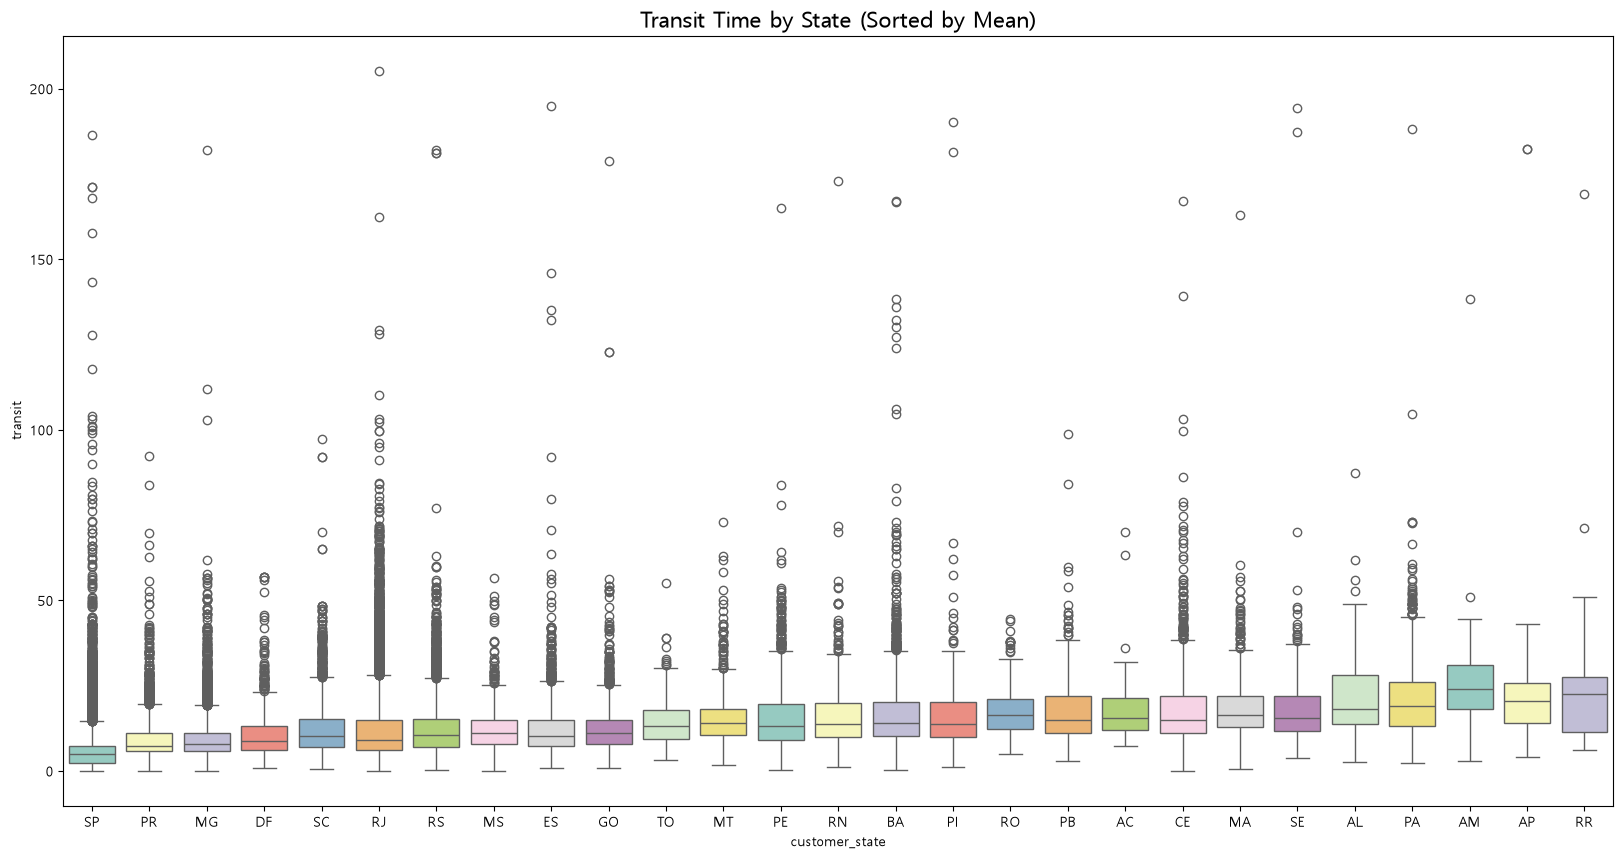

In [61]:
# customer_state별로 deliver의 평균값을 계산하고, 
# 그 평균값을 기준으로 오름차순으로 정렬한 후, customer_state 컬럼을 정렬된 순서대로 박스플롯 그리기.

# customer_state별 deliver 평균값 계산 후 정렬
sorted_states = df.groupby("customer_state")["transit"].mean().sort_values(ascending=True).index

# customer_state 컬럼을 정렬된 순서로 설정
df["customer_state"] = pd.Categorical(df["customer_state"], categories=sorted_states, ordered=True)

# 박스플롯 그리기
fig = plt.figure(figsize=(20, 10)) # 크기
sns.boxplot(x="customer_state", y="transit", data=df, palette="Set3")
plt.title("Transit Time by State (Sorted by Mean)", fontsize=16)
plt.show()

In [62]:
# 타지역 대비 평균배송시간이 빠른 브라질 주들의 위도, 경도 좌표(SP, PR, MG, DF, SC, RS, GO, RJ, MS, ES)
states_coords = {
    'SP': (-23.5505, -46.6333),
    'PR': (-25.4296, -49.2733),
    'MG': (-19.9245, -43.9352),
    'DF': (-15.8267, -47.9218),
    'SC': (-27.5954, -48.5480),
    'RJ': (-22.9068, -43.1729),
    'RS': (-30.0346, -51.2177),
    'ES': (-19.3170, -40.3363),
    'GO': (-16.6869, -49.2643),
    'MS': (-20.4697, -54.6200) 
}

# 위도, 경도와 주 이름을 DataFrame으로 변환
data = pd.DataFrame(states_coords.items(), columns=["State", "Coordinates"])
data['Lat'] = data['Coordinates'].apply(lambda x: x[0]) # 위도
data['Lon'] = data['Coordinates'].apply(lambda x: x[1]) # 경도

# Plotly 지도 생성
fig = px.scatter_geo(data, lat='Lat', lon='Lon', text='State', 
                     title='Brazil States with Points', 
                     projection="natural earth")
fig.show()

# 주요 대도시 남쪽 도시들의 배송 시간이 짧고 효율적이며,북쪽 도시는 비교적 배송 시간이 오래 걸린다.
# 지리적 특성이 배송에 악영향을 미치는 지역에 대해 추가적인 물류 허브 설립 또는 배송 프로세스 최적화 필요하다.

In [63]:
# 빠른 주 / 느린 주 좌표 (주도 기준)
fast_states = {
    'SP':(-23.5505,-46.6333), 
    'PR':(-25.4296,-49.2733), 
    'MG':(-19.9245,-43.9352),
    'DF':(-15.8267,-47.9218), 
    'SC':(-27.5954,-48.5480), 
    'RJ':(-22.9068,-43.1729)
    }
slow_states = {
    'RR':(2.8235,-60.6758), 
    'AP':(0.0349,-51.0694), 
    'AM':(-3.1190,-60.0217),
    'AL':(-9.6498,-35.7089), 
    'PA':(-1.4558,-48.4902), 
    'MA':(-2.5307,-44.3068)
    }

# 하나의 DataFrame으로 합치고 구분 컬럼(Category) 추가
rows = [(s, la, lo, 'Fast_States') for s,(la,lo) in fast_states.items()] + \
       [(s, la, lo, 'Slow_States') for s,(la,lo) in slow_states.items()]

data = pd.DataFrame(rows, columns=['State','Lat','Lon','Category'])

# 지도: 빠른(초록) vs 느린(빨강) 구분
fig = px.scatter_geo(data, lat='Lat', lon='Lon', text='State', color='Category',
                     color_discrete_map={'Fast_States':'green','Slow_States':'red'},
                     title='Brazil: Fast vs Slow Delivery States',
                     projection='natural earth')
fig.update_traces(marker=dict(size=10))
fig.update_geos(scope='south america')   # 브라질 잘 보이게 확대
fig.show()
# 주요 대도시 남쪽 도시들의 배송 시간이 짧고 효율적이며,북쪽 도시는 비교적 배송 시간이 오래 걸린다.
# 지리적 특성이 배송에 악영향을 미치는 지역에 대해 추가적인 물류 허브 설립 또는 배송 프로세스 최적화 필요하다.


## 5. 고객 분포 분석(step2)

In [64]:
# state 위도 경도
geo_state_lat = df_geo.groupby('geolocation_state')['geolocation_lat'].mean().reset_index()
geo_state_lng = df_geo.groupby('geolocation_state')['geolocation_lng'].mean().reset_index()
geo_state_lat.rename(columns={'geolocation_lat': 'customer_state_lat'}, inplace=True)
geo_state_lng.rename(columns={'geolocation_lng': 'customer_state_lng'}, inplace=True)

# city 평균 위도 경도
geo_city_lat = df_geo.groupby('geolocation_city')['geolocation_lat'].mean().reset_index()
geo_city_lng = df_geo.groupby('geolocation_city')['geolocation_lng'].mean().reset_index()
geo_city_lat.rename(columns={'geolocation_lat': 'customer_city_lat'}, inplace=True)
geo_city_lng.rename(columns={'geolocation_lng':'customer_city_lng'}, inplace=True)

# 테이블 결합
df = pd.merge(df, geo_state_lat, how='left', left_on='customer_state',right_on='geolocation_state')
df = pd.merge(df, geo_state_lng, how='left', left_on='customer_state',right_on='geolocation_state')
df = pd.merge(df, geo_city_lat,  how='left', left_on='customer_city' ,right_on='geolocation_city')
df = pd.merge(df, geo_city_lng,  how='left', left_on='customer_city' ,right_on='geolocation_city')

# # 불필요한 컬럼 제거
df = df.drop('geolocation_city_x', axis=1) # lat 조인시
df = df.drop('geolocation_city_y', axis=1) # lng 조인시
df = df.drop('geolocation_state_x', axis=1) # lat 조인시
df = df.drop('geolocation_state_y', axis=1) # lng 조인시

# 테이블 조회
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_score,delay,deliver,transit,preprocessing,value,customer_state_lat,customer_state_lng,customer_city_lat,customer_city_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,4.0,-7.107488,8.436574,6.062650,2.366493,38.71,-23.155308,-47.084074,-23.570860,-46.633242
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,5.0,-12.980069,13.208750,9.450498,3.745833,72.20,-5.856702,-35.990079,-4.864240,-36.839625
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,5.0,-9.238171,2.873877,1.937824,0.893113,28.62,-23.155308,-47.084074,-23.655241,-46.519084
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1,060cb19345d90064d1015407193c233d,...,4.0,-5.543113,16.542245,14.833229,1.699896,175.26,-24.793607,-50.879662,-23.553522,-50.549924
4,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1,4520766ec412348b8d4caa5e8a18c464,...,5.0,-11.461215,9.989826,4.116725,5.864988,75.16,-22.743477,-43.155540,-22.809790,-43.418223


In [65]:
geo_state_lat

,geolocation_state,customer_state_lat
0,AC,-9.702555
1,AL,-9.599729
2,AM,-3.349336
3,AP,0.086025
4,BA,-13.049361
5,CE,-4.363151
6,DF,-15.810885
7,ES,-20.105145
8,GO,-16.577645
9,MA,-3.798997


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93437 entries, 0 to 93436
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       93437 non-null  str           
 1   customer_id                    93437 non-null  str           
 2   order_status                   93437 non-null  str           
 3   order_purchase_timestamp       93437 non-null  datetime64[us]
 4   order_approved_at              93437 non-null  datetime64[us]
 5   order_delivered_carrier_date   93437 non-null  datetime64[us]
 6   order_delivered_customer_date  93437 non-null  datetime64[us]
 7   order_estimated_delivery_date  93437 non-null  datetime64[us]
 8   order_item_id                  93437 non-null  int64         
 9   product_id                     93437 non-null  str           
 10  seller_id                      93437 non-null  str           
 11  shipping_limit_date       

In [67]:
# state 주문수 및 평균주문시간 
state_order = df.groupby(['customer_state','customer_state_lng','customer_state_lat'])['order_id'].count().to_frame().reset_index()
state_deliver = df.groupby(['customer_state','customer_state_lng','customer_state_lat'])['transit'].mean().reset_index()
state_deliver['text'] = ('state :' + state_deliver['customer_state'].astype(str)
                         + ' | transit: ' + state_deliver['transit'].round(1).astype(str)
                         + ' | order: '   + state_order['order_id'].astype(str))

# city 주문수 및 평균주문시간 
city_order = df.groupby(['customer_city','customer_city_lng','customer_city_lat'])['order_id'].count().to_frame().reset_index()
city_deliver = df.groupby(['customer_city','customer_city_lng','customer_city_lat'])['transit'].mean().reset_index()
city_deliver['text'] = ('city :' + city_deliver['customer_city'].astype(str)
                        + ' | transit: ' + city_deliver['transit'].round(1).astype(str)
                        + ' | order: '   + city_order['order_id'].astype(str))

# state 및 city 주문수 및 평균주문시간 지도 그리기
# 주문수(크기) / 평균주문시간(색 강조)
data = [
    go.Scattergeo(
    lon = state_order['customer_state_lng'], # 'customer_state_lng' 열에 저장된 경도 값 사용
    lat = state_order['customer_state_lat'], # 'customer_state_lat' 열에 저장된 위도 값 사용
    text = state_deliver['text'], # 'text' 열의 텍스트를 각 포인트에 표시
    marker = dict(
        size = state_order['order_id'] / 50, # 'order_id'를 50으로 나눈 값을 마커의 크기로 사용
        sizemin = 1, # 마커의 최소 크기 설정
        color= state_deliver['transit'], # 'transit' 열의 값을 마커 색상으로 사용
        colorscale= 'Greens', # 색상 스케일을 'Greens'로 설정
        cmin = state_deliver['transit'].min(), # 색상의 최소값을 'transit'의 최소값으로 설정
        cmax = state_deliver['transit'].mean(), # 색상의 최대값을 'transit'의 평균값으로 설정
        line = dict(width=0.1, color='rgb(40,40,40)'), # 마커 테두리 설정: 색상은 회색, 두께는 0.1
        sizemode = 'area' # 마커 크기 모드 설정: 크기는 면적에 비례
        ),
    name = 'State'
    ),
    go.Scattergeo(
        lon = city_order['customer_city_lng'],
        lat = city_order['customer_city_lat'],
        text = city_deliver['text'],
        marker = dict(
            size = city_order['order_id'] / 50,
            sizemin = 1,
            color = city_deliver['transit'],
            colorscale = 'Reds',
            cmin = city_deliver['transit'].min(),
            cmax = city_deliver['transit'].mean(),
            line = dict(width=0.1, color='rgb(40,40,40)'),
            sizemode = 'area'
        ),
        name = 'City'    
    )
]

layout = dict(
    title = 'Brazilian E-commerce Order and deliver Values',  # 제목을 설정: 지도에 표시될 제목
    showlegend = True,  # 범례(legend) 표시 여부 설정
    autosize=True,  # 자동 크기 조정 활성화
    # 그래프의 너비와 높이 설정
    width = 900,  
    height = 600,  
    
    geo = dict(
        scope = "south america",  # 지도 범위 설정: 남미 대륙을 기준으로 표시
        projection = dict(type='winkel tripel', scale = 1.6), # 지도 투영 방법 설정: 'winkel tripel' 투영 방식 사용, 비율은 1.6으로 설정
        center = dict(lon=-47, lat=-22),  # 지도 중심을 설정: 중심을 위도 -22, 경도 -47로 설정
        showland = True,  # 지도에서 육지의 표시 여부
        showcountries = True,  # 국가의 표시 여부
        showsubunits = True,  # 국가의 하위 단위 표시 여부
        landcolor = 'rgb(155, 155, 155)',  # 육지의 색상 설정
        subunitwidth = 1,  # 국가 하위 단위(예: 주) 경계 두께 설정
        countrywidth = 1,  # 국가 경계 두께 설정
        subunitcolor="rgb(255, 255, 255)",  # 하위 단위 경계 색상 설정
        countrycolor="rgb(255, 255, 255)"  # 국가 경계 색상 설정
    )
)
fig = dict( data=data, layout=layout )
pio.show(fig)

# 대도시 고객 및 주문수 많으며, 배송시간도 짧다.

In [68]:
slow = df[df['deliver'] >= 30]
slow.info()

<class 'pandas.DataFrame'>
Index: 4804 entries, 25 to 93426
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       4804 non-null   str           
 1   customer_id                    4804 non-null   str           
 2   order_status                   4804 non-null   str           
 3   order_purchase_timestamp       4804 non-null   datetime64[us]
 4   order_approved_at              4804 non-null   datetime64[us]
 5   order_delivered_carrier_date   4804 non-null   datetime64[us]
 6   order_delivered_customer_date  4804 non-null   datetime64[us]
 7   order_estimated_delivery_date  4804 non-null   datetime64[us]
 8   order_item_id                  4804 non-null   int64         
 9   product_id                     4804 non-null   str           
 10  seller_id                      4804 non-null   str           
 11  shipping_limit_date            

In [69]:
# state 주문수 및 평균주문시간 
state_order = slow.groupby(['customer_state','customer_state_lng','customer_state_lat'])['order_id'].count().to_frame().reset_index()
state_deliver = slow.groupby(['customer_state','customer_state_lng','customer_state_lat'])['transit'].mean().reset_index()
state_deliver['text'] = ('state :' + state_deliver['customer_state'].astype(str)
                         + ' | transit: ' + state_deliver['transit'].round(1).astype(str)
                         + ' | order: '   + state_order['order_id'].astype(str))

# city 주문수 및 평균주문시간 
city_order = slow.groupby(['customer_city','customer_city_lng','customer_city_lat'])['order_id'].count().to_frame().reset_index()
city_deliver = slow.groupby(['customer_city','customer_city_lng','customer_city_lat'])['transit'].mean().reset_index()
city_deliver['text'] = ('city :' + city_deliver['customer_city'].astype(str)
                        + ' | transit: ' + city_deliver['transit'].round(1).astype(str)
                        + ' | order: '   + city_order['order_id'].astype(str))

# state 및 city 주문수 및 평균주문시간 지도 그리기
# 주문수(크기) / 평균주문시간(색 강조)
data = [
    go.Scattergeo(
    lon = state_order['customer_state_lng'], # 'customer_state_lng' 열에 저장된 경도 값 사용
    lat = state_order['customer_state_lat'], # 'customer_state_lat' 열에 저장된 위도 값 사용
    text = state_deliver['text'], # 'text' 열의 텍스트를 각 포인트에 표시
    marker = dict(
        size = state_order['order_id'] / 50, # 'order_id'를 50으로 나눈 값을 마커의 크기로 사용
        sizemin = 1, # 마커의 최소 크기 설정
        color= state_deliver['transit'], # 'transit' 열의 값을 마커 색상으로 사용
        colorscale= 'Greens', # 색상 스케일을 'Greens'로 설정
        cmin = state_deliver['transit'].min(), # 색상의 최소값을 'transit'의 최소값으로 설정
        cmax = state_deliver['transit'].mean(), # 색상의 최대값을 'transit'의 평균값으로 설정
        line = dict(width=0.1, color='rgb(40,40,40)'), # 마커 테두리 설정: 색상은 회색, 두께는 0.1
        sizemode = 'area' # 마커 크기 모드 설정: 크기는 면적에 비례
        ),
    name = 'State'
    ),
    go.Scattergeo(
        lon = city_order['customer_city_lng'],
        lat = city_order['customer_city_lat'],
        text = city_deliver['text'],
        marker = dict(
            size = city_order['order_id'] / 50,
            sizemin = 1,
            color = city_deliver['transit'],
            colorscale = 'Reds',
            cmin = city_deliver['transit'].min(),
            cmax = city_deliver['transit'].mean(),
            line = dict(width=0.1, color='rgb(40,40,40)'),
            sizemode = 'area'
        ),
        name = 'City'    
    )
]

layout = dict(
    title = 'Brazilian E-commerce delay Order and deliver Values',  # 제목을 설정: 지도에 표시될 제목
    showlegend = True,  # 범례(legend) 표시 여부 설정
    autosize=True,  # 자동 크기 조정 활성화
    # 그래프의 너비와 높이 설정
    width = 900,  
    height = 600,  
    
    geo = dict(
        scope = "south america",  # 지도 범위 설정: 남미 대륙을 기준으로 표시
        projection = dict(type='winkel tripel', scale = 1.6), # 지도 투영 방법 설정: 'winkel tripel' 투영 방식 사용, 비율은 1.6으로 설정
        center = dict(lon=-47, lat=-22),  # 지도 중심을 설정: 중심을 위도 -22, 경도 -47로 설정
        showland = True,  # 지도에서 육지의 표시 여부
        showcountries = True,  # 국가의 표시 여부
        showsubunits = True,  # 국가의 하위 단위 표시 여부
        landcolor = 'rgb(155, 155, 155)',  # 육지의 색상 설정
        subunitwidth = 1,  # 국가 하위 단위(예: 주) 경계 두께 설정
        countrywidth = 1,  # 국가 경계 두께 설정
        subunitcolor="rgb(255, 255, 255)",  # 하위 단위 경계 색상 설정
        countrycolor="rgb(255, 255, 255)"  # 국가 경계 색상 설정
    )
)
fig = dict( data=data, layout=layout )
pio.show(fig)

# 대도시 고객 및 주문수 많으며, 배송시간도 짧다.

## 6. 판매자 분포 분석

In [70]:
# state 위도 경도
geo_state_lat = df_geo.groupby('geolocation_state')['geolocation_lat'].mean().reset_index()
geo_state_lng = df_geo.groupby('geolocation_state')['geolocation_lng'].mean().reset_index()
geo_state_lat.rename(columns={'geolocation_lat': 'seller_state_lat'}, inplace=True)
geo_state_lng.rename(columns={'geolocation_lng': 'seller_state_lng'}, inplace=True)

# city 평균 위도 경도
geo_city_lat = df_geo.groupby('geolocation_city')['geolocation_lat'].mean().reset_index()
geo_city_lng = df_geo.groupby('geolocation_city')['geolocation_lng'].mean().reset_index()
geo_city_lat.rename(columns={'geolocation_lat': 'seller_city_lat'}, inplace=True)
geo_city_lng.rename(columns={'geolocation_lng':'seller_city_lng'}, inplace=True)

# 테이블 결합
df = pd.merge(df, geo_state_lat, how='left', left_on='seller_state',right_on='geolocation_state')
df = pd.merge(df, geo_state_lng, how='left', left_on='seller_state',right_on='geolocation_state')
df = pd.merge(df, geo_city_lat,  how='left', left_on='seller_city' ,right_on='geolocation_city')
df = pd.merge(df, geo_city_lng,  how='left', left_on='seller_city' ,right_on='geolocation_city')

# 불필요한 컬럼 제거
df = df.drop('geolocation_city_x', axis=1)
df = df.drop('geolocation_city_y', axis=1)
df = df.drop('geolocation_state_x', axis=1)
df = df.drop('geolocation_state_y', axis=1)

# 테이블 조회
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,preprocessing,value,customer_state_lat,customer_state_lng,customer_city_lat,customer_city_lng,seller_state_lat,seller_state_lng,seller_city_lat,seller_city_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2.366493,38.71,-23.155308,-47.084074,-23.570860,-46.633242,-23.155308,-47.084074,-23.669994,-46.448909
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.745833,72.20,-5.856702,-35.990079,-4.864240,-36.839625,-19.864647,-44.421615,-19.908772,-43.957549
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,0.893113,28.62,-23.155308,-47.084074,-23.655241,-46.519084,-23.155308,-47.084074,-23.530402,-46.193888
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1,060cb19345d90064d1015407193c233d,...,1.699896,175.26,-24.793607,-50.879662,-23.553522,-50.549924,-23.155308,-47.084074,-23.446403,-46.498768
4,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1,4520766ec412348b8d4caa5e8a18c464,...,5.864988,75.16,-22.743477,-43.155540,-22.809790,-43.418223,-23.155308,-47.084074,-23.123135,-46.560482


In [71]:
# state 주문수 및 평균주문시간 
state_order = df.groupby(['seller_state','seller_state_lng','seller_state_lat'])['order_id'].count().to_frame().reset_index()
state_deliver = df.groupby(['seller_state','seller_state_lng','seller_state_lat'])['transit'].mean().reset_index()
state_deliver['text'] = 'state :' + state_deliver['seller_state'] + ' | deliver: ' + state_deliver['transit'].astype(str) + ' | order: ' + state_order['order_id'].astype(str)

# city 주문수 및 평균주문시간 
city_order = df.groupby(['seller_city','seller_city_lng','seller_city_lat'])['order_id'].count().to_frame().reset_index()
city_deliver = df.groupby(['seller_city','seller_city_lng','seller_city_lat'])['transit'].mean().reset_index()
city_deliver['text'] = 'city :' + city_deliver['seller_city'] + ' | transit: ' + city_deliver['transit'].astype(str) + ' | order: ' + city_order['order_id'].astype(str)

# state 및 city 주문수 및 평균주문시간 지도 그리기
# 주문수(크기) / 평균주문시간(색 강조)
data = [
    go.Scattergeo(
    lon = state_order['seller_state_lng'],
    lat = state_order['seller_state_lat'],
    text = state_deliver['text'],
    marker = dict(
        size = state_order['order_id']/50,
        sizemin = 1,
        color= state_deliver['transit'],
        colorscale= 'Oranges',
        cmin = state_deliver['transit'].min(),
        cmax = state_deliver['transit'].mean(),
        line = dict(width=0.1, color='rgb(40,40,40)'),
        sizemode = 'area'
        ),
    name = 'State'
    ),
    go.Scattergeo(
        lon = city_order['seller_city_lng'],
        lat = city_order['seller_city_lat'],
        text = city_deliver['text'],
        marker = dict(
            size = city_order['order_id'] / 50,
            sizemin = 1,
            color = city_deliver['transit'],
            colorscale = 'Blues',
            cmin = city_deliver['transit'].min(),
            cmax = city_deliver['transit'].mean(),
            line = dict(width=0.1, color='rgb(40,40,40)'),
            sizemode = 'area'
        ),
        name = 'City'    
    )
]

layout = dict(
        title = 'Brazilian E-commerce Order and deliver Values',
        showlegend = True,
        autosize=True,
        width = 900,
        height = 600,
        geo = dict(
            scope = "south america",
            projection = dict(type='winkel tripel', scale = 1.6),
            center = dict(lon=-47,lat=-22),
            showland = True,
            showcountries= True,
            showsubunits=True,
            landcolor = 'rgb(155, 155, 155)',
            subunitwidth=1,
            countrywidth=1,
            subunitcolor="rgb(255, 255, 255)",
            countrycolor="rgb(255, 255, 255)"
        )
    )
fig = dict( data=data, layout=layout )
pio.show(fig)

# 대도시 판매자 수가 압도적으로 많이 분포한디.

In [72]:
# 30일 이상 배송 지연 주문만 필터링
slow = df[df['deliver'] >= 30]

# state 주문수 및 평균주문시간 
state_order = slow.groupby(['seller_state','seller_state_lng','seller_state_lat'])['order_id'].count().to_frame().reset_index()
state_deliver = slow.groupby(['seller_state','seller_state_lng','seller_state_lat'])['transit'].mean().reset_index()
state_deliver['text'] = 'state :' + state_deliver['seller_state'] + ' | deliver: ' + state_deliver['transit'].astype(str) + ' | order: ' + state_order['order_id'].astype(str)

# city 주문수 및 평균주문시간 
city_order = slow.groupby(['seller_city','seller_city_lng','seller_city_lat'])['order_id'].count().to_frame().reset_index()
city_deliver = slow.groupby(['seller_city','seller_city_lng','seller_city_lat'])['transit'].mean().reset_index()
city_deliver['text'] = 'city :' + city_deliver['seller_city'] + ' | transit: ' + city_deliver['transit'].astype(str) + ' | order: ' + city_order['order_id'].astype(str)

# state 및 city 주문수 및 평균주문시간 지도 그리기
# 주문수(크기) / 평균주문시간(색 강조)
data = [
    go.Scattergeo(
    lon = state_order['seller_state_lng'],
    lat = state_order['seller_state_lat'],
    text = state_deliver['text'],
    marker = dict(
        size = state_order['order_id']/50,
        sizemin = 1,
        color= state_deliver['transit'],
        colorscale= 'Oranges',
        cmin = state_deliver['transit'].min(),
        cmax = state_deliver['transit'].mean(),
        line = dict(width=0.1, color='rgb(40,40,40)'),
        sizemode = 'area'
        ),
    name = 'State'
    ),
    go.Scattergeo(
        lon = city_order['seller_city_lng'],
        lat = city_order['seller_city_lat'],
        text = city_deliver['text'],
        marker = dict(
            size = city_order['order_id'] / 50,
            sizemin = 1,
            color = city_deliver['transit'],
            colorscale = 'Blues',
            cmin = city_deliver['transit'].min(),
            cmax = city_deliver['transit'].mean(),
            line = dict(width=0.1, color='rgb(40,40,40)'),
            sizemode = 'area'
        ),
        name = 'City'    
    )
]

layout = dict(
        title = 'Brazilian E-commerce Slow Delivery Order and deliver Values',
        showlegend = True,
        autosize=True,
        width = 900,
        height = 600,
        geo = dict(
            scope = "south america",
            projection = dict(type='winkel tripel', scale = 1.6),
            center = dict(lon=-47,lat=-22),
            showland = True,
            showcountries= True,
            showsubunits=True,
            landcolor = 'rgb(155, 155, 155)',
            subunitwidth=1,
            countrywidth=1,
            subunitcolor="rgb(255, 255, 255)",
            countrycolor="rgb(255, 255, 255)"
        )
    )
fig = dict( data=data, layout=layout )
pio.show(fig)

# 대도시 판매자 수가 압도적으로 많이 분포한디.

## 7. 고객 및 판매자 분포 분석

In [73]:
# city 고객 주문수 및 평균주문시간 
customer_city_order = df.groupby(['customer_city','customer_city_lng','customer_city_lat'])['order_id'].count().to_frame().reset_index()
customer_city_deliver = df.groupby(['customer_city','customer_city_lng','customer_city_lat'])['transit'].mean().reset_index()
customer_city_deliver['text'] = 'city :' + customer_city_deliver['customer_city'] + ' | transit: ' + customer_city_deliver['transit'].astype(str) + ' | order: ' + customer_city_order['order_id'].astype(str)

# city 판매자 주문수 및 평균주문시간 
seller_city_order = df.groupby(['seller_city','seller_city_lng','seller_city_lat'])['order_id'].count().to_frame().reset_index()
seller_city_deliver = df.groupby(['seller_city','seller_city_lng','seller_city_lat'])['transit'].mean().reset_index()
seller_city_deliver['text'] = 'city :' + seller_city_deliver['seller_city'] + ' | transit: ' + seller_city_deliver['transit'].astype(str) + ' | order: ' + seller_city_order['order_id'].astype(str)

# 고객 및 판매자별 주문수 및 평균주문시간 지도 그리기
# 주문수(크기) / 평균주문시간(색 강조)
data = [
    go.Scattergeo(
    lon = customer_city_order['customer_city_lng'],
    lat = customer_city_order['customer_city_lat'],
    text = customer_city_deliver['text'],
    marker = dict(
        size = customer_city_order['order_id']/50,
        sizemin = 1,
        color= customer_city_deliver['transit'],
        colorscale= 'Greens',
        cmin = customer_city_deliver['transit'].min(),
        cmax = customer_city_deliver['transit'].mean(),
        line = dict(width=0.1, color='rgb(40,40,40)'),
        sizemode = 'area'
        ),
    name = 'customer'
    ),
    go.Scattergeo(
        lon = seller_city_order['seller_city_lng'],
        lat = seller_city_order['seller_city_lat'],
        text = seller_city_deliver['text'],
        marker = dict(
            size = seller_city_order['order_id'] / 50,
            sizemin = 1,
            color = seller_city_deliver['transit'],
            colorscale = 'Reds',
            cmin = seller_city_deliver['transit'].min(),
            cmax = seller_city_deliver['transit'].mean(),
            line = dict(width=0.1, color='rgb(40,40,40)'),
            sizemode = 'area'
        ),
        name = 'seller'    
    )
]

layout = dict(
        title = 'Brazilian E-commerce Order and deliver Values',
        showlegend = True,
        autosize=True,
        width = 900,
        height = 600,
        geo = dict(
            scope = "south america",
            projection = dict(type='winkel tripel', scale = 1.6),
            center = dict(lon=-47,lat=-22),
            showland = True,
            showcountries= True,
            showsubunits=True,
            landcolor = 'rgb(155, 155, 155)',
            subunitwidth=1,
            countrywidth=1,
            subunitcolor="rgb(255, 255, 255)",
            countrycolor="rgb(255, 255, 255)"
        )
    )
fig = dict( data=data, layout=layout )
pio.show(fig)

# 배송 프로세스 최적화를 위해, 물류 허브 설립 필요하다.

In [74]:
#Slow 데이터셋을 사용하여, 30일 이상 배송 지연 주문만 필터링한 후, 고객 및 판매자별 주문수 및 평균주문시간 지도 그리기

# city 고객 주문수 및 평균주문시간 
customer_city_order = slow.groupby(['customer_city','customer_city_lng','customer_city_lat'])['order_id'].count().to_frame().reset_index()
customer_city_deliver = slow.groupby(['customer_city','customer_city_lng','customer_city_lat'])['transit'].mean().reset_index()
customer_city_deliver['text'] = 'city :' + customer_city_deliver['customer_city'] + ' | transit: ' + customer_city_deliver['transit'].astype(str) + ' | order: ' + customer_city_order['order_id'].astype(str)

# city 판매자 주문수 및 평균주문시간 
seller_city_order = slow.groupby(['seller_city','seller_city_lng','seller_city_lat'])['order_id'].count().to_frame().reset_index()
seller_city_deliver = slow.groupby(['seller_city','seller_city_lng','seller_city_lat'])['transit'].mean().reset_index()
seller_city_deliver['text'] = 'city :' + seller_city_deliver['seller_city'] + ' | transit: ' + seller_city_deliver['transit'].astype(str) + ' | order: ' + seller_city_order['order_id'].astype(str)

# 고객 및 판매자별 주문수 및 평균주문시간 지도 그리기
# 주문수(크기) / 평균주문시간(색 강조)
data = [
    go.Scattergeo(
    lon = customer_city_order['customer_city_lng'],
    lat = customer_city_order['customer_city_lat'],
    text = customer_city_deliver['text'],
    marker = dict(
        size = customer_city_order['order_id']/50,
        sizemin = 1,
        color= customer_city_deliver['transit'],
        colorscale= 'Greens',
        cmin = customer_city_deliver['transit'].min(),
        cmax = customer_city_deliver['transit'].mean(),
        line = dict(width=0.1, color='rgb(40,40,40)'),
        sizemode = 'area'
        ),
    name = 'customer'
    ),
    go.Scattergeo(
        lon = seller_city_order['seller_city_lng'],
        lat = seller_city_order['seller_city_lat'],
        text = seller_city_deliver['text'],
        marker = dict(
            size = seller_city_order['order_id'] / 50,
            sizemin = 1,
            color = seller_city_deliver['transit'],
            colorscale = 'Reds',
            cmin = seller_city_deliver['transit'].min(),
            cmax = seller_city_deliver['transit'].mean(),
            line = dict(width=0.1, color='rgb(40,40,40)'),
            sizemode = 'area'
        ),
        name = 'seller'    
    )
]

layout = dict(
        title = 'Brazilian E-commerce Slow Delivery Order and deliver Values',
        showlegend = True,
        autosize=True,
        width = 900,
        height = 600,
        geo = dict(
            scope = "south america",
            projection = dict(type='winkel tripel', scale = 1.6),
            center = dict(lon=-47,lat=-22),
            showland = True,
            showcountries= True,
            showsubunits=True,
            landcolor = 'rgb(155, 155, 155)',
            subunitwidth=1,
            countrywidth=1,
            subunitcolor="rgb(255, 255, 255)",
            countrycolor="rgb(255, 255, 255)"
        )
    )
fig = dict( data=data, layout=layout )
pio.show(fig)

# 배송 프로세스 최적화를 위해, 물류 허브 설립 필요하다.

## 8. 판매자 및 고객 위도 경도 두 지점 간의 최단 거리 구하기(Step3)

In [75]:
# 판매자 위도 경도 컬럼 생성
# 주소 위도 경도
geo_zip_code_lat = df_geo.groupby('geolocation_zip_code_prefix')['geolocation_lat'].mean().reset_index()
geo_zip_code_lng = df_geo.groupby('geolocation_zip_code_prefix')['geolocation_lng'].mean().reset_index()
geo_zip_code_lat.rename(columns={'geolocation_lat': 'seller_zip_code_lat'}, inplace=True)
geo_zip_code_lng.rename(columns={'geolocation_lng': 'seller_zip_code_lng'}, inplace=True)

# 테이블 결합
df = pd.merge(df, geo_zip_code_lat, how='left', left_on='seller_zip_code_prefix',right_on='geolocation_zip_code_prefix')
df = pd.merge(df, geo_zip_code_lng, how='left', left_on='seller_zip_code_prefix',right_on='geolocation_zip_code_prefix')

# 불필요한 컬럼 삭제
df = df.drop('geolocation_zip_code_prefix_x', axis=1)
df = df.drop('geolocation_zip_code_prefix_y', axis=1)

# 고객 위도 경도 컬럼 생성
# 판매자 위도 경도 -> 고객 위도 경도 컬럼 변경
geo_zip_code_lat.rename(columns={'seller_zip_code_lat': 'customer_zip_code_lat'}, inplace=True)
geo_zip_code_lng.rename(columns={'seller_zip_code_lng': 'customer_zip_code_lng'}, inplace=True)

# 테이블 결합
df = pd.merge(df, geo_zip_code_lat, how='left', left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix')
df = pd.merge(df, geo_zip_code_lng, how='left', left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix')

# 불필요한 컬럼 삭제
df = df.drop('geolocation_zip_code_prefix_x', axis=1)
df = df.drop('geolocation_zip_code_prefix_y', axis=1)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city_lat,customer_city_lng,seller_state_lat,seller_state_lng,seller_city_lat,seller_city_lng,seller_zip_code_lat,seller_zip_code_lng,customer_zip_code_lat,customer_zip_code_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,-23.570860,-46.633242,-23.155308,-47.084074,-23.669994,-46.448909,-23.680729,-46.444238,-23.576983,-46.587161
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,-4.864240,-36.839625,-19.864647,-44.421615,-19.908772,-43.957549,-19.837682,-43.924053,-5.774190,-35.271143
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,-23.655241,-46.519084,-23.155308,-47.084074,-23.530402,-46.193888,-23.543395,-46.262086,-23.676370,-46.514627
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1,060cb19345d90064d1015407193c233d,...,-23.553522,-50.549924,-23.155308,-47.084074,-23.446403,-46.498768,-23.468704,-46.516142,-23.553522,-50.549924
4,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1,4520766ec412348b8d4caa5e8a18c464,...,-22.809790,-43.418223,-23.155308,-47.084074,-23.123135,-46.560482,-23.114731,-46.552881,-22.805707,-43.423079


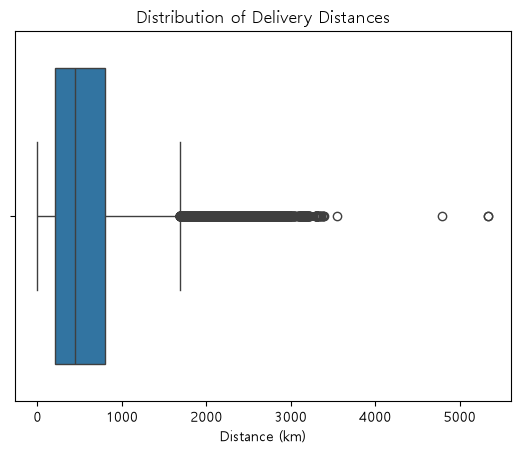

중앙값: 439.0 km
가장 많은 주문이 포함된 구간: (0.0, 100.0], 해당 구간에 주문수는 16597 이다.


In [76]:
# 두 지점간의 최단거리 구하기, 하버사인 공식(Haversine Formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# 최단거리 컬럼 생성
df['distance_km'] = haversine(df['seller_zip_code_lat'], df['seller_zip_code_lng'], df['customer_zip_code_lat'], df['customer_zip_code_lng'])

# 박스플롯 생성
sns.boxplot(data=df, x='distance_km')
plt.title('Distribution of Delivery Distances')
plt.xlabel('Distance (km)')
plt.show()

# 중앙값
median_distance = round(df['distance_km'].median(), 0)
print(f"중앙값: {median_distance} km")

# 배송거리 100km 구간별로 나눠, 가장 주문 수가 많은 구간과 해당 구간의 주문 수 계산
df['distance_bin'] = pd.cut(df['distance_km'], bins=np.arange(0, df['distance_km'].max() + 100, 100))
# df['distance_km'].max() + 100: + 100을 하는 이유는 최대 거리 값도 마지막 구간에 포함되도록 하기 위해서

bin_counts = df['distance_bin'].value_counts().sort_index()
most_common_bin = bin_counts.idxmax()
# idxmax: 최댓값을 가지는 인덱스를 반환하는 함수
most_common_count = bin_counts.max()
# max: 최댓값을 반환하는 함수
print(f"가장 많은 주문이 포함된 구간: {most_common_bin}, 해당 구간에 주문수는 {most_common_count} 이다.")

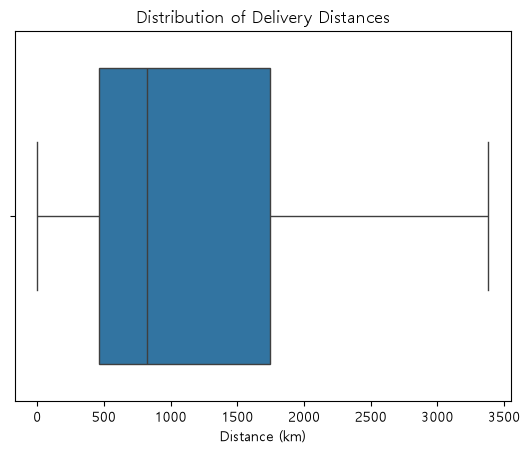

중앙값: 825.0 km
가장 많은 주문이 포함된 구간: (300.0, 400.0], 해당 구간에 주문수는 594 이다.


In [77]:
slow = df[df['deliver'] >= 30]

# 두 지점간의 최단거리 구하기, 하버사인 공식(Haversine Formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# 최단거리 컬럼 생성
slow['distance_km'] = haversine(slow['seller_zip_code_lat'], slow['seller_zip_code_lng'], slow['customer_zip_code_lat'], slow['customer_zip_code_lng'])

# 박스플롯 생성
sns.boxplot(data=slow, x='distance_km')
plt.title('Distribution of Delivery Distances')
plt.xlabel('Distance (km)')
plt.show()

# 중앙값
median_distance = round(slow['distance_km'].median(), 0)
print(f"중앙값: {median_distance} km")

# 배송거리 100km 구간별로 나눠, 가장 주문 수가 많은 구간과 해당 구간의 주문 수 계산
slow['distance_bin'] = pd.cut(slow['distance_km'], bins=np.arange(0, slow['distance_km'].max() + 100, 100))
# slow['distance_km'].max() + 100: + 100을 하는 이유는 최대 거리 값도 마지막 구간에 포함되도록 하기 위해서

bin_counts = slow['distance_bin'].value_counts().sort_index()
most_common_bin = bin_counts.idxmax()
# idxmax: 최댓값을 가지는 인덱스를 반환하는 함수
most_common_count = bin_counts.max()
# max: 최댓값을 반환하는 함수
print(f"가장 많은 주문이 포함된 구간: {most_common_bin}, 해당 구간에 주문수는 {most_common_count} 이다.")


## 9. 지역별 배송거리 분석

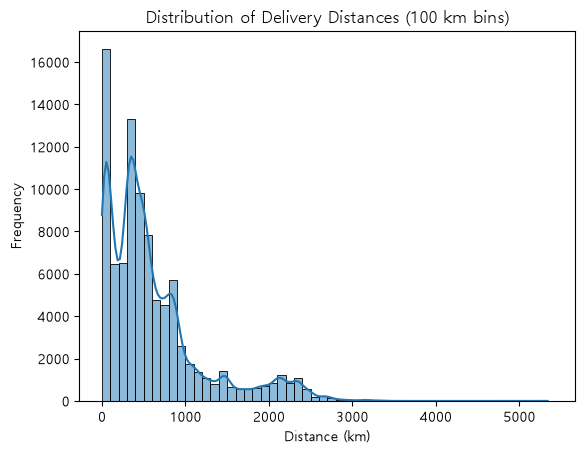

100km 이상 구간의 주문 비중: 81.71%


In [78]:
# 배송거리 100km 구간
bins = np.arange(0, df['distance_km'].max() + 100, 100)

# 배송거리 100km 구간별 주문수
sns.histplot(df['distance_km'], bins=bins, kde=True)
plt.title('Distribution of Delivery Distances (100 km bins)')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

# 100km 이상인 주문 수의 비중
count_over_100km = (df['distance_km'] >= 100).sum()
total_count = len(df)
percentage_over_100km = (count_over_100km / total_count) * 100
print(f"100km 이상 구간의 주문 비중: {percentage_over_100km:.2f}%")
# 2f: 소수점 이하 두 자리까지 표시하는 실수 서식

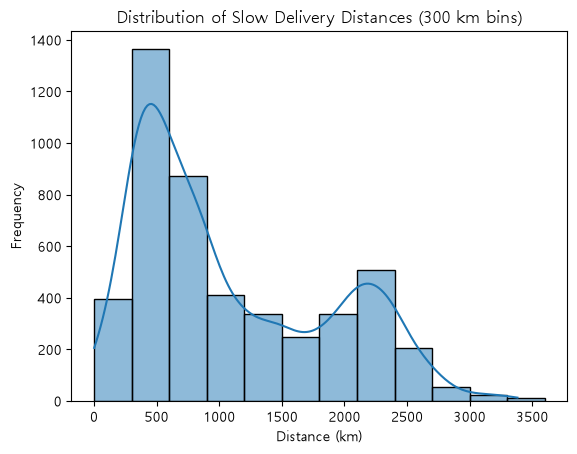

300km 이상 구간의 주문 비중: 91.09%


In [79]:
# 배송거리 100km 구간
bins = np.arange(0, slow['distance_km'].max() + 100, 100)

# 배송거리 300km 구간
bins = np.arange(0, slow['distance_km'].max() + 300, 300)

# 배송거리 300km 구간별 주문수
sns.histplot(slow['distance_km'], bins=bins, kde=True)
plt.title('Distribution of Slow Delivery Distances (300 km bins)')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

# 300km 이상인 주문 수의 비중
count_over_300km = (slow['distance_km'] >= 300).sum()
total_count = len(slow)
percentage_over_300km = (count_over_300km / total_count) * 100
print(f"300km 이상 구간의 주문 비중: {percentage_over_300km:.2f}%")
# 2f: 소수점 이하 두 자리까지 표시하는 실수 서식

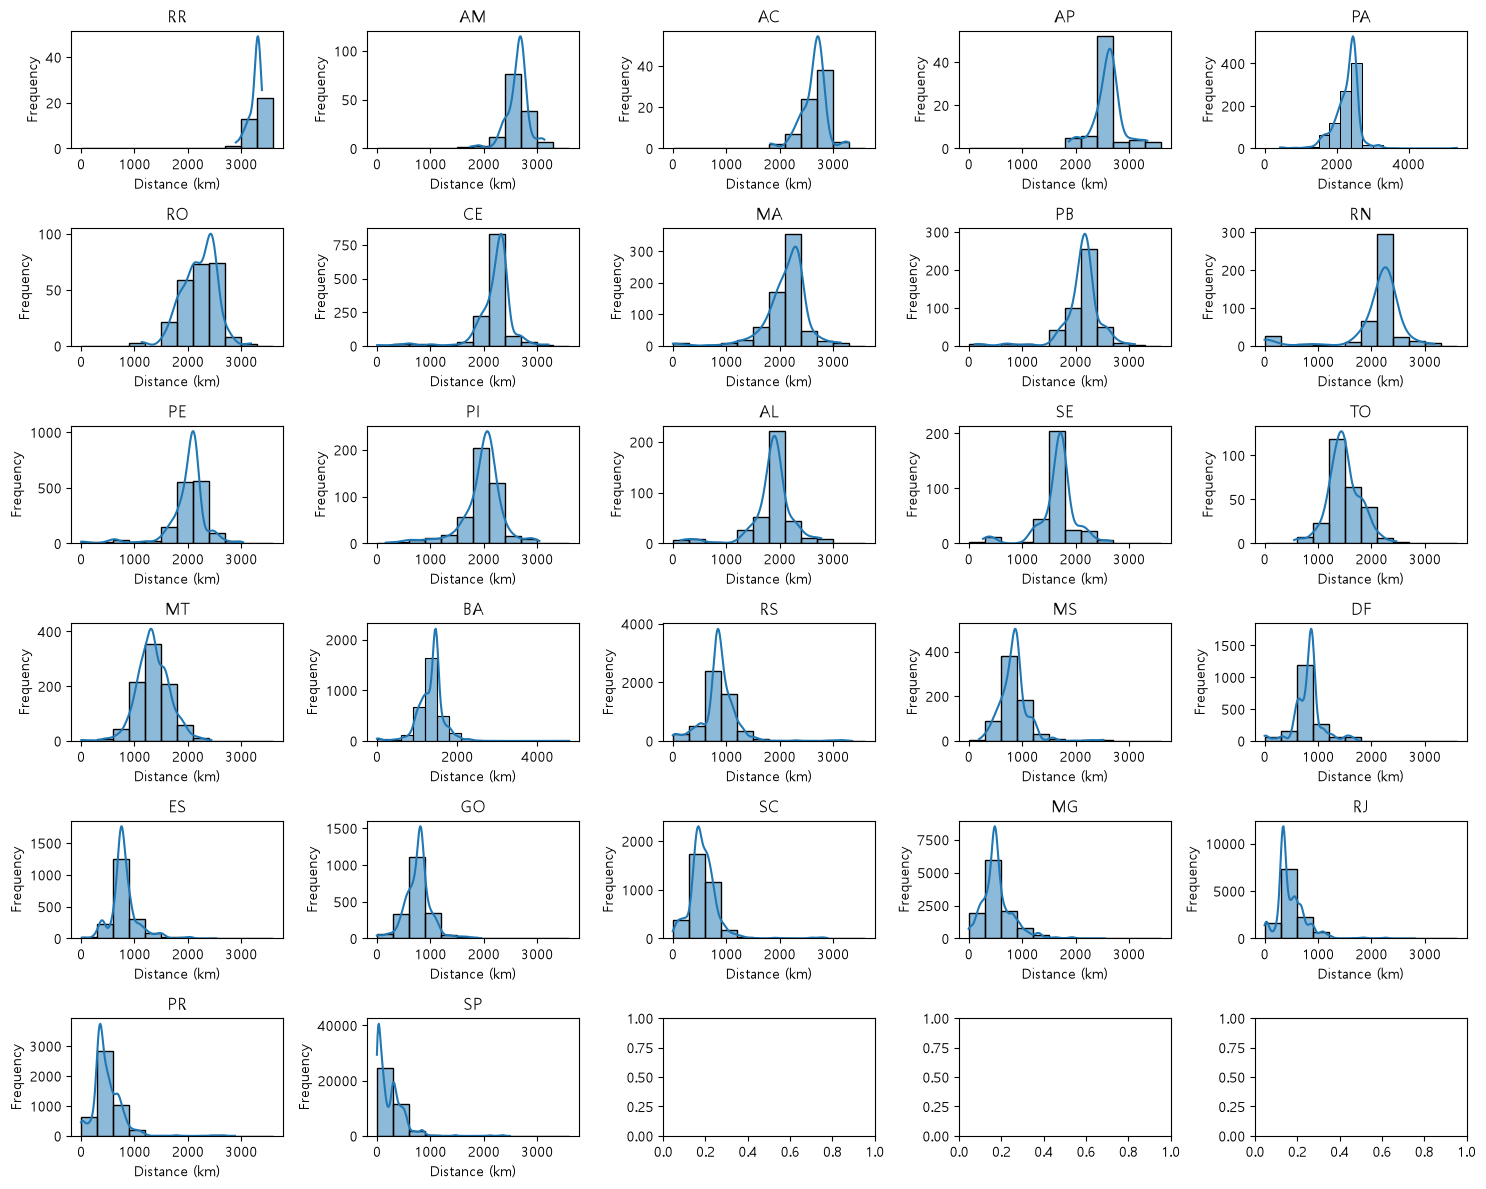

In [80]:
# 고유한 customer_state 값 가져오기
states = df['customer_state'].unique()

# 각 state별 평균 distance_km 계산
state_means = {state: df[df['customer_state'] == state]['distance_km'].mean() for state in states}

# 평균값을 기준으로 states 정렬 (내림차순: reverse=True)
sorted_states = sorted(state_means, key=state_means.get, reverse=True)

# 6x5 그리드 설정
n_rows = 6
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

# 각 state별로 히스토그램 그리기
for i, state in enumerate(sorted_states):
    row = i // n_cols  # 행 위치
    col = i % n_cols   # 열 위치

    # 특정 state의 데이터 필터링
    state_data = df[df['customer_state'] == state]
    
    # 각 서브플롯에 히스토그램 그리기
    sns.histplot(state_data['distance_km'], bins=bins, kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'{state}')
    axes[row, col].set_xlabel('Distance (km)')
    axes[row, col].set_ylabel('Frequency')

# 레이아웃 조정
plt.tight_layout()
plt.show()

In [81]:
# 브라질 주들의 위도, 경도 좌표(RR, AM, AC, AP, PA, RO, CE, MA, PB, RN, PE, PI, AL, SE, TO)
states_coords = {
    'RR': (-1.4425, -62.0702),
    'AM': (-3.4653, -62.2159),
    'AC': (-8.7736, -70.0555),
    'AP': (1.4117, -51.7719),
    'PA': (-5.7945, -53.1416),
    'RO': (-10.1615, -64.6017),
    'CE': (-5.3983, -39.3206),
    'MA': (-5.1106, -45.8740),
}

# 위도, 경도와 주 이름을 DataFrame으로 변환
data = pd.DataFrame(states_coords.items(), columns=["State", "Coordinates"])
data['Lat'] = data['Coordinates'].apply(lambda x: x[0])
data['Lon'] = data['Coordinates'].apply(lambda x: x[1])

# Plotly 지도 생성
fig = px.scatter_geo(data, lat='Lat', lon='Lon', text='State', 
                     title='Brazil States with Points', 
                     projection="natural earth")
fig.update_geos(scope='south america')   # 브라질 잘 보이게 확대
fig.show()

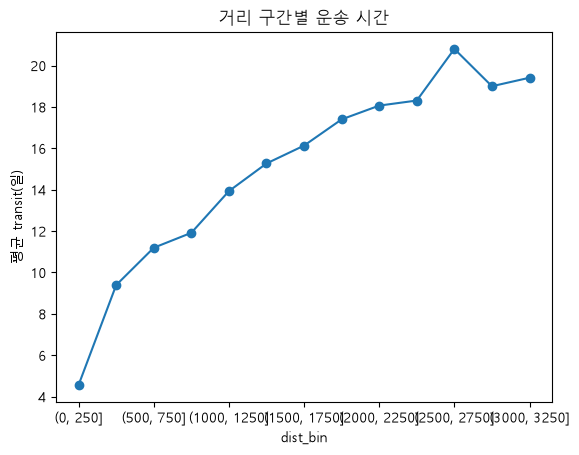

상관계수: 0.42


In [82]:
# 거리 구간별 운송 시간 분석

df['dist_bin'] = pd.cut(df['distance_km'], np.arange(0, 3500, 250))
df.groupby('dist_bin')['transit'].mean().plot(marker='o')
plt.ylabel('평균 transit(일)'); plt.title('거리 구간별 운송 시간'); plt.show()
print('상관계수:', round(df[['distance_km','transit']].corr().iloc[0,1], 2))

In [83]:
from scipy.stats import spearmanr
print('스피어만 상관계수:', round(spearmanr(df['distance_km'], df['transit'], nan_policy='omit').correlation, 2))
print('피어슨 상관계수:', round(df[['distance_km', 'transit']].corr().iloc[0, 1], 2))

스피어만 상관계수: 0.61
피어슨 상관계수: 0.42


In [84]:
#허브 후보 요약 표
hub = (df[df['deliver']>=30].groupby('customer_state')
       .agg(orders=('order_id','nunique'),
            avg_transit=('transit','mean'),
            avg_distance=('distance_km','mean'))
       .sort_values('orders', ascending=False))
print(hub.head(10))

# 주별 좌표 붙이기 
coords = df.groupby('customer_state')[['customer_state_lat','customer_state_lng']].first()
hub_map = hub.join(coords).reset_index()
hub_map['customer_state'] = hub_map['customer_state'].astype(str)

# 지도: 크기=느린 주문수, 색=평균 운송일
import plotly.express as px
fig = px.scatter_geo(hub_map,
                     lat='customer_state_lat', lon='customer_state_lng',
                     size='orders',                 # 느린 주문 많을수록 큰 점
                     color='avg_transit',           # 운송 길수록 진한 색
                     text='customer_state',
                     color_continuous_scale='Reds',
                     size_max=40,
                     title='허브 후보: 30일+ 느린 주문 지역 (크기=주문수, 색=운송일)',
                     projection='natural earth')
fig.update_geos(scope='south america')
fig.show()

                orders  avg_transit  avg_distance
customer_state                                   
RJ                1125    36.737391    539.473523
SP                 479    30.138242    357.762880
BA                 371    35.168877   1401.340674
RS                 333    33.494498    977.894753
MG                 250    28.663710    553.261233
SC                 205    30.987343    654.059154
PA                 203    37.060883   2250.819653
CE                 187    38.483550   2238.133086
PE                 164    35.862406   2067.372238
MA                 112    32.767330   2178.199995


In [85]:
print(df_order.groupby('customer_state')['review_score'].mean().sort_values().head(10))

customer_state
RR    3.727273
MA    3.813002
SE    3.820789
AL    3.833333
PA    3.848447
BA    3.882651
CE    3.901447
RJ    3.923671
PI    3.995134
AC    4.014493
Name: review_score, dtype: float64
